# Task 21: RNN / LSTM / GRU for IMDB Sequence Classification

**Goal**: Build sequence classification models step by step.

---

# Step 1: Import libraries

In [22]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset

---

# Step 2: Setup device

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


---

# Step 3: Load dataset

In [24]:
df = pd.read_csv(Path.cwd() / "datasets" / "imdb_balanced_10k.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 2)


,text,label
0,"Unreal ""movie"", what were these people on?? A ...",0
1,"Without Peter Ustinov and Maggie Smith, this c...",1
2,This is the true story of how three British so...,1
3,This movie appears to have designed as a Fred ...,1
4,"Daniel Day-Lewis is Christy Brown, a victim of...",1


---

# Step 4: Clean and tokenize text

In [25]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

tokenized_text = [tokenize(text) for text in df["text"]]

print("First sample tokens:")
print(tokenized_text[0][:20])

First sample tokens:
['unreal', 'movie', 'what', 'were', 'these', 'people', 'on', 'a', 'mix', 'of', 'french', 'upstairs', 'downstairs', 'mating', 'horsesporn', 'not', 'suggested', 'its', 'pretty', 'full']


---

# Step 5: Build vocabulary

In [26]:
all_words = [word for sentence in tokenized_text for word in sentence]

vocab = {
    word: i + 2
    for i, (word, _) in enumerate(Counter(all_words).most_common(5000))
}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocabulary size:", len(vocab))
print("First 10 vocab items:")
print(list(vocab.items())[:10])

Vocabulary size: 5002
First 10 vocab items:
[('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10), ('this', 11)]


---

# Step 6: Convert text to sequences

In [27]:
def text_to_seq(text_list, max_len=200):

    seqs = []

    for sentence in text_list:

        seq = [vocab.get(word, 1) for word in sentence]

        if len(seq) < max_len:
            seq = seq + [0] * (max_len - len(seq))
        else:
            seq = seq[:max_len]

        seqs.append(seq)

    return seqs

X = torch.tensor(text_to_seq(tokenized_text), dtype=torch.long)

y = torch.tensor(df["label"].values, dtype=torch.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([10000, 200])
y shape: torch.Size([10000])


---

# Step 7: Split dataset

In [28]:
train_idx = int(0.8 * len(X))

X_train = X[:train_idx]
X_test = X[train_idx:]

y_train = y[:train_idx]
y_test = y[train_idx:]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 8000
Test samples: 2000


---

# Step 8: Build model

In [29]:
class SequenceClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, model_type="RNN"):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        if model_type == "RNN":
            self.rnn = nn.RNN(
                embed_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

        elif model_type == "LSTM":
            self.rnn = nn.LSTM(
                embed_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

        elif model_type == "GRU":
            self.rnn = nn.GRU(
                embed_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):

        embedded = self.embedding(x)

        out, _ = self.rnn(embedded)

        pooled = out.mean(dim=1)

        pooled = self.dropout(pooled)

        logits = self.fc(pooled)

        return logits

---

# Step 9: Build training function

In [30]:
def train_and_eval(model_type="RNN", epochs=50):

    model = SequenceClassifier(
        vocab_size=len(vocab),
        embed_dim=128,
        hidden_dim=128,
        model_type=model_type
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.BCEWithLogitsLoss()

    history = []

    print(f"Training {model_type}...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for batch_x, batch_y in train_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(batch_x).squeeze()

            loss = criterion(logits, batch_y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5
            )

            optimizer.step()

            total_loss += loss.item()

        model.eval()

        correct = 0

        with torch.no_grad():

            for bx, by in test_loader:

                bx = bx.to(device)
                by = by.to(device)

                probs = torch.sigmoid(
                    model(bx).squeeze()
                )

                preds = (probs > 0.5).float()

                correct += (preds == by).sum().item()

        acc = correct / len(test_loader.dataset)

        history.append(acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {total_loss / len(train_loader):.4f} | "
            f"Test Acc: {acc:.4f}"
        )

    return history

---

# Step 10: Train RNN

In [31]:
rnn_hist = train_and_eval("RNN", epochs=50)

Training RNN...
Epoch 1/50 | Loss: 0.6199 | Test Acc: 0.7720
Epoch 2/50 | Loss: 0.4406 | Test Acc: 0.8220
Epoch 3/50 | Loss: 0.3433 | Test Acc: 0.8360
Epoch 4/50 | Loss: 0.2832 | Test Acc: 0.8415
Epoch 5/50 | Loss: 0.2457 | Test Acc: 0.8525
Epoch 6/50 | Loss: 0.1944 | Test Acc: 0.8450
Epoch 7/50 | Loss: 0.1593 | Test Acc: 0.8480
Epoch 8/50 | Loss: 0.1233 | Test Acc: 0.8365
Epoch 9/50 | Loss: 0.1031 | Test Acc: 0.8355
Epoch 10/50 | Loss: 0.0856 | Test Acc: 0.8345
Epoch 11/50 | Loss: 0.0591 | Test Acc: 0.8365
Epoch 12/50 | Loss: 0.0413 | Test Acc: 0.8305
Epoch 13/50 | Loss: 0.0437 | Test Acc: 0.8280
Epoch 14/50 | Loss: 0.2576 | Test Acc: 0.8430
Epoch 15/50 | Loss: 0.0609 | Test Acc: 0.8385
Epoch 16/50 | Loss: 0.0255 | Test Acc: 0.8295
Epoch 17/50 | Loss: 0.0150 | Test Acc: 0.8310
Epoch 18/50 | Loss: 0.0085 | Test Acc: 0.8310
Epoch 19/50 | Loss: 0.0052 | Test Acc: 0.8345
Epoch 20/50 | Loss: 0.0035 | Test Acc: 0.8335
Epoch 21/50 | Loss: 0.0029 | Test Acc: 0.8340
Epoch 22/50 | Loss: 0.0020 

---

# Step 11: Train LSTM

In [32]:
lstm_hist = train_and_eval("LSTM", epochs=50)

Training LSTM...
Epoch 1/50 | Loss: 0.6163 | Test Acc: 0.7400
Epoch 2/50 | Loss: 0.4330 | Test Acc: 0.7980
Epoch 3/50 | Loss: 0.3179 | Test Acc: 0.8505
Epoch 4/50 | Loss: 0.2439 | Test Acc: 0.8430
Epoch 5/50 | Loss: 0.1924 | Test Acc: 0.8515
Epoch 6/50 | Loss: 0.1313 | Test Acc: 0.8565
Epoch 7/50 | Loss: 0.1019 | Test Acc: 0.8445
Epoch 8/50 | Loss: 0.0562 | Test Acc: 0.8520
Epoch 9/50 | Loss: 0.0426 | Test Acc: 0.8465
Epoch 10/50 | Loss: 0.0301 | Test Acc: 0.8560
Epoch 11/50 | Loss: 0.0280 | Test Acc: 0.8510
Epoch 12/50 | Loss: 0.0180 | Test Acc: 0.8455
Epoch 13/50 | Loss: 0.0185 | Test Acc: 0.8570
Epoch 14/50 | Loss: 0.0100 | Test Acc: 0.8475
Epoch 15/50 | Loss: 0.0083 | Test Acc: 0.8450
Epoch 16/50 | Loss: 0.0079 | Test Acc: 0.8430
Epoch 17/50 | Loss: 0.0103 | Test Acc: 0.8525
Epoch 18/50 | Loss: 0.0075 | Test Acc: 0.8460
Epoch 19/50 | Loss: 0.0131 | Test Acc: 0.8435
Epoch 20/50 | Loss: 0.0096 | Test Acc: 0.8530
Epoch 21/50 | Loss: 0.0080 | Test Acc: 0.8505
Epoch 22/50 | Loss: 0.0171

---

# Step 12: Train GRU

In [33]:
gru_hist = train_and_eval("GRU", epochs=50)

Training GRU...
Epoch 1/50 | Loss: 0.6031 | Test Acc: 0.7640
Epoch 2/50 | Loss: 0.3899 | Test Acc: 0.8425
Epoch 3/50 | Loss: 0.2801 | Test Acc: 0.8590
Epoch 4/50 | Loss: 0.2108 | Test Acc: 0.8600
Epoch 5/50 | Loss: 0.1450 | Test Acc: 0.8610
Epoch 6/50 | Loss: 0.0890 | Test Acc: 0.8625
Epoch 7/50 | Loss: 0.0554 | Test Acc: 0.8475
Epoch 8/50 | Loss: 0.0350 | Test Acc: 0.8460
Epoch 9/50 | Loss: 0.0292 | Test Acc: 0.8445
Epoch 10/50 | Loss: 0.0270 | Test Acc: 0.8575
Epoch 11/50 | Loss: 0.0073 | Test Acc: 0.8525
Epoch 12/50 | Loss: 0.0075 | Test Acc: 0.8565
Epoch 13/50 | Loss: 0.0056 | Test Acc: 0.8635
Epoch 14/50 | Loss: 0.0086 | Test Acc: 0.8550
Epoch 15/50 | Loss: 0.0101 | Test Acc: 0.8520
Epoch 16/50 | Loss: 0.0126 | Test Acc: 0.8565
Epoch 17/50 | Loss: 0.0076 | Test Acc: 0.8555
Epoch 18/50 | Loss: 0.0029 | Test Acc: 0.8540
Epoch 19/50 | Loss: 0.0005 | Test Acc: 0.8535
Epoch 20/50 | Loss: 0.0003 | Test Acc: 0.8525
Epoch 21/50 | Loss: 0.0002 | Test Acc: 0.8510
Epoch 22/50 | Loss: 0.0001 

---

# Step 13: Compare results

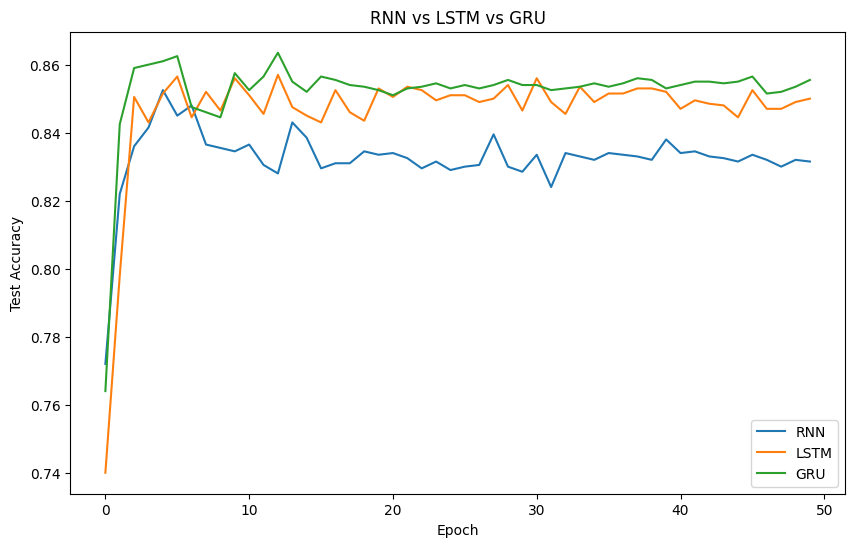

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(rnn_hist, label="RNN")
plt.plot(lstm_hist, label="LSTM")
plt.plot(gru_hist, label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")

plt.title("RNN vs LSTM vs GRU")

plt.legend()

plt.show()

---

# Step 14: Print best accuracy

In [35]:
print("Best RNN Accuracy:", max(rnn_hist))
print("Best LSTM Accuracy:", max(lstm_hist))
print("Best GRU Accuracy:", max(gru_hist))

Best RNN Accuracy: 0.8525
Best LSTM Accuracy: 0.857
Best GRU Accuracy: 0.8635
